# CS+AO Sea Ice Thickness

- Description: Sea ice thickness derived from CryoSat-2 radar freeboard combined with the Altimetric Snow Depth snow solution.
- Original data source: http://cryosat.mssl.ucl.ac.uk/csao/public-docs.html
- Reference: http://cryosat.mssl.ucl.ac.uk/csao/DD5_V1.1.pdf
- OSC entry: https://opensciencedata.esa.int/products/southern-ocean-sit-from-cryosat-2/collection
- License: CC-BY-NC-4.0

Access notebook goal: open the remote Zarr store, pick one month, mask out open ocean, and make a readable sea-ice thickness map.

In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature

DATA_URL = "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/polar_cube_datasets/cs+ao/cs_plus.zarr"
THICKNESS = "SIT_ASD_mean"
CONCENTRATION = "sea_ice_conc"
MIN_CONCENTRATION = 15

Open only the metadata first. The data remains lazy until a later cell asks for a plot or a number.

In [2]:
ds = xr.open_zarr(DATA_URL, consolidated=True, chunks={})
ds[[THICKNESS, CONCENTRATION]]

<xarray.Dataset> Size: 385MB
Dimensions:       (time: 94, y: 712, x: 712)
Coordinates:
    lat           (y, x) float32 2MB dask.array<chunksize=(356, 356), meta=np.ndarray>
    lon           (y, x) float32 2MB dask.array<chunksize=(356, 356), meta=np.ndarray>
  * time          (time) datetime64[ns] 752B 2013-03-16 ... 2020-12-16
  * x             (x) float32 3kB 6.25e+03 1.875e+04 ... 8.881e+06 8.894e+06
  * y             (y) float32 3kB 8.894e+06 8.881e+06 ... 1.875e+04 6.25e+03
Data variables:
    SIT_ASD_mean  (time, y, x) float32 191MB dask.array<chunksize=(1, 356, 356), meta=np.ndarray>
    sea_ice_conc  (time, y, x) float32 191MB dask.array<chunksize=(1, 356, 356), meta=np.ndarray>
Attributes: (12/55)
    projection:              laea
    lat_ts:                  0.0
    lon_0:                   0
    lat_0:                   -90
    resolution:              c
    pixel_size:              12500
    ...                      ...
    out_file_name:           /work/ALT/odatis/seaice/data/grids_seaice/sh/712...
    start_date:              20170101
    end_date:                20170201
    date_of_creation:        2023-04-01 16:25
    legos_command:           /work/ALT/odatis/seaice/modules/ct_tools/2.18/sc...
    legos_creation_date:     2023-04-01 15:42

Select the latest available month and keep only plausible sea-ice thickness where concentration is at least 15 percent.

In [3]:
month = ds["time"].isel(time=-1)
month_label = str(month.values)[:7]

thickness = ds[THICKNESS].sel(time=month)
concentration = ds[CONCENTRATION].sel(time=month)

thickness = thickness.where(concentration >= MIN_CONCENTRATION)
thickness = thickness.where((thickness >= 0) & (thickness <= 20))
thickness.name = "sea_ice_thickness_m"

thickness

<xarray.DataArray 'sea_ice_thickness_m' (y: 712, x: 712)> Size: 2MB
dask.array<where, shape=(712, 712), dtype=float32, chunksize=(356, 356), chunktype=numpy.ndarray>
Coordinates:
    lat      (y, x) float32 2MB dask.array<chunksize=(356, 356), meta=np.ndarray>
    lon      (y, x) float32 2MB dask.array<chunksize=(356, 356), meta=np.ndarray>
    time     datetime64[ns] 8B 2020-12-16
  * x        (x) float32 3kB 6.25e+03 1.875e+04 ... 8.881e+06 8.894e+06
  * y        (y) float32 3kB 8.894e+06 8.881e+06 ... 1.875e+04 6.25e+03
Attributes:
    long_name:  sea_ice_thickness
    units:      m
    comment:    Sea ice thickness from radar_freeboard where nsidc ice concen...

In [4]:
mean_thickness = thickness.mean(skipna=True).compute()

print(f"Demo month: {month_label}")
print(f"Mean sea-ice thickness where concentration >= {MIN_CONCENTRATION}%: {float(mean_thickness):.2f} m")

Demo month: 2020-12
Mean sea-ice thickness where concentration >= 15%: 1.07 m


Plot the same month on a simple south polar map.

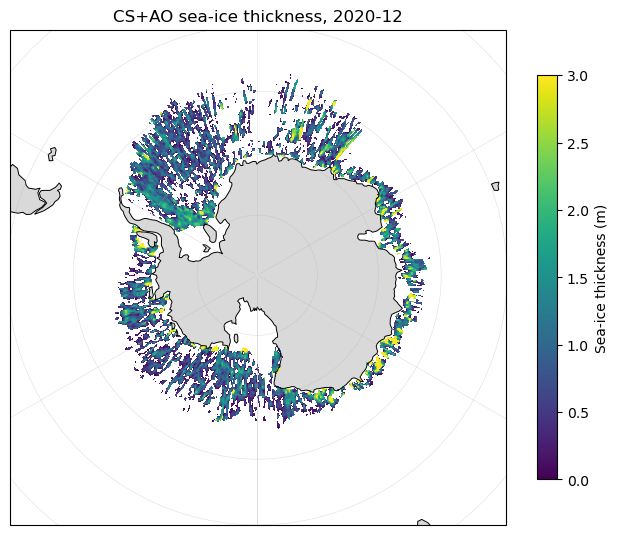

In [5]:
plot_data = thickness.compute()

fig = plt.figure(figsize=(8, 7))
ax = plt.axes(projection=ccrs.SouthPolarStereo())

mesh = ax.pcolormesh(
    ds["lon"],
    ds["lat"],
    plot_data,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="viridis",
    vmin=0,
    vmax=3,
)
fig.colorbar(mesh, ax=ax, shrink=0.75, pad=0.05, label="Sea-ice thickness (m)")

ax.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="0.85", zorder=0)
ax.coastlines(linewidth=0.7)
ax.gridlines(draw_labels=False, linewidth=0.4, alpha=0.4)
ax.set_title(f"CS+AO sea-ice thickness, {month_label}")

plt.show()